In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from imblearn.combine import SMOTEENN
from sklearn.svm import LinearSVC
from imblearn.under_sampling import RandomUnderSampler
from sklearn.neural_network import MLPClassifier
import shap
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)



#1.Merging 2 input files into 1
df1 = pd.read_csv("customer_churn_dataset-testing.csv")
df2 = pd.read_csv("customer_churn_dataset-training.csv")
df = pd.concat([df1, df2], axis=0, ignore_index=True)
print("Total rows and columns:",df.shape)


#2.Drop Nulls
df.dropna(inplace=True)
print("After Dropping Nulls:",df.shape)

#Converting float to int
float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].round().astype('int64')

#3.Feature Engineering
subscription_map = {
    'Basic': 2,  
    'Premium': 1,
    'Standard': 3  #highest churn
}
contract_map = {
    'Monthly': 3,  #highest impact
    'Quarterly': 1,
    'Annual': 2
}

df['Subscription Type']=df['Subscription Type'].map(subscription_map)
df['Contract Length']=df['Contract Length'].map(contract_map)

df['Subscription_Contract'] = (df['Subscription Type']  + (df['Contract Length']-1)**2) 

#4.Drop unnessary columns
Irr_cols= ['Subscription Type', 'Contract Length','CustomerID']
df=df.drop(columns= Irr_cols, axis=1)

#5.Encoding
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

#6.select features and target variable
X = df.drop('Churn', axis=1)
y = df['Churn']

#7.Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Total rows and columns: (505207, 12)
After Dropping Nulls: (505206, 12)


In [4]:
def final_model(method=None):
    global X_train, y_train, X_test, y_test
    #8.Sampling
    if method=="SMOTEENN":
        smoteenn = SMOTEENN(random_state=42)
        X_train, y_train = smoteenn.fit_resample(X_train, y_train)
        print("Smote Done!!!")
    elif method=="RandomUnderSampler":
        undersampler = RandomUnderSampler(random_state=42)
        X_train, y_train = undersampler.fit_resample(X_train, y_train)
        print("RandomUnderSampler Done!!!")

    # 9.Scale numeric features
    numeric_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls','Payment Delay', 'Total Spend', 'Last Interaction','Subscription_Contract']
    scaler = StandardScaler()
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

    models={'LogisticRegression' : (LogisticRegression(), {'C': [0.1, 1, 10], 'max_iter': [500, 1000]}),
        'RandomForestClassifier': (RandomForestClassifier(n_jobs=-1, random_state=42),{'n_estimators': [10,50,100], 'max_depth': [10, 15]}),
        'SVM': (LinearSVC(random_state=42, max_iter=5000),{'C': [0.01, 0.1, 1, 10]}),
        'ANN': (MLPClassifier(max_iter=500),{'hidden_layer_sizes': [(10,), (20,)],'activation': ['relu'],'solver': ['adam'],'learning_rate_init': [0.001, 0.01]})
        }
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    metrics_cols = ['model_name','t_accuracy','t_precision','t_recall','t_f1']

    model_name=[]
    t_accuracy=[]
    t_precision=[]
    t_recall=[]
    t_f1=[]
    best_params = []
    roc_curves = []

    for nam, (model, params) in models.items():
        r_search = RandomizedSearchCV(model, param_distributions=params, n_iter=5, cv=skf,scoring='accuracy',n_jobs=-1)
        y_pred=r_search.fit(X_train, y_train)
        best_model = r_search.best_estimator_
        y_pred = best_model.predict(X_test)
        
        model_name.append(type(best_model).__name__)
        t_accuracy.append(int(round(accuracy_score(y_test, y_pred) * 100)))
        t_precision.append(int(round(precision_score(y_test, y_pred, average='binary') * 100)))
        t_recall.append(int(round(recall_score(y_test, y_pred, average='binary') * 100)))
        t_f1.append(int(round(f1_score(y_test, y_pred, average='binary') * 100)))
        best_params.append(r_search.best_params_)

        if method is None:
            cm = confusion_matrix(y_test, y_pred)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm)
            disp.plot(cmap=plt.cm.Blues)
            plt.title(f"Confusion Matrix - {nam}")
            plt.show()

                # ROC Curve
            if hasattr(best_model, "predict_proba"):
                y_prob = best_model.predict_proba(X_test)[:, 1]
            else:
                y_prob = best_model.decision_function(X_test)

            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            roc_curves.append((fpr, tpr, roc_auc, nam))
    
      # Plot all ROC curves together

    if method is None:
        plt.figure(figsize=(10, 7))
        for fpr, tpr, roc_auc, nam in roc_curves:
            plt.plot(fpr, tpr, lw=2, label=f"{nam} (AUC={roc_auc:.2f})")

        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve Comparison Across Models")
        plt.legend()
        plt.grid(True)
        plt.show()


    # Create DataFrame
    metrics_dict = {'model': model_name,
        'accuracy': t_accuracy,
        'precision': t_precision,
        'recall': t_recall,
        'f1': t_f1,
        'best_params': best_params
    }

    model_metrics = pd.DataFrame(metrics_dict).sort_values('accuracy', ascending=False)
    return model_metrics

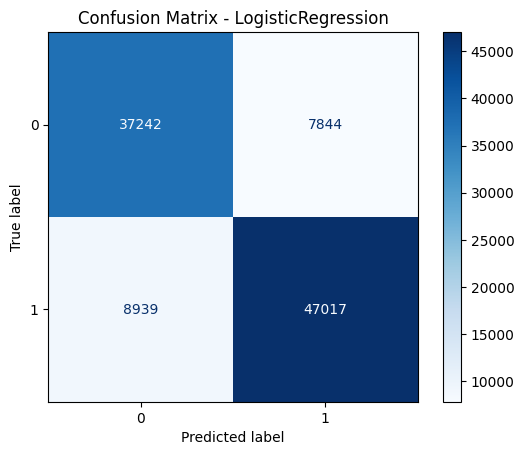

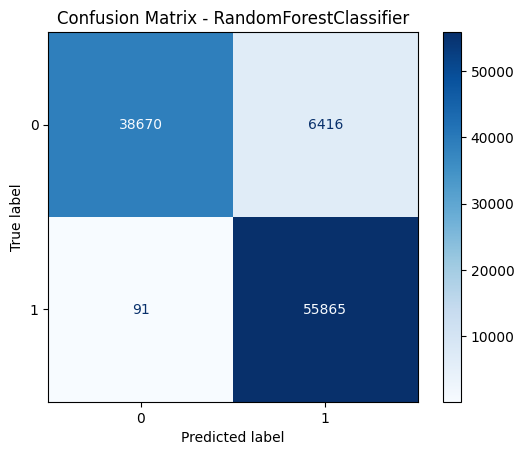

C:\Users\JANANI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


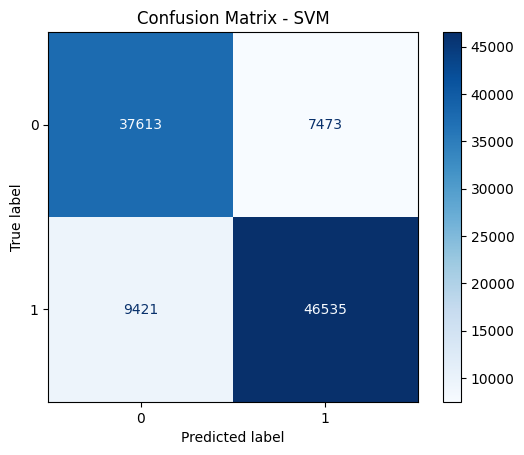

C:\Users\JANANI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


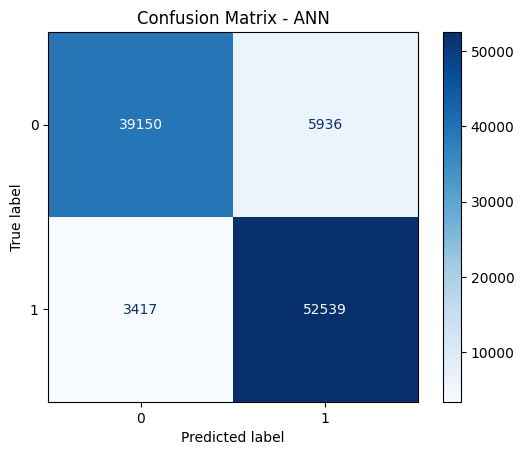

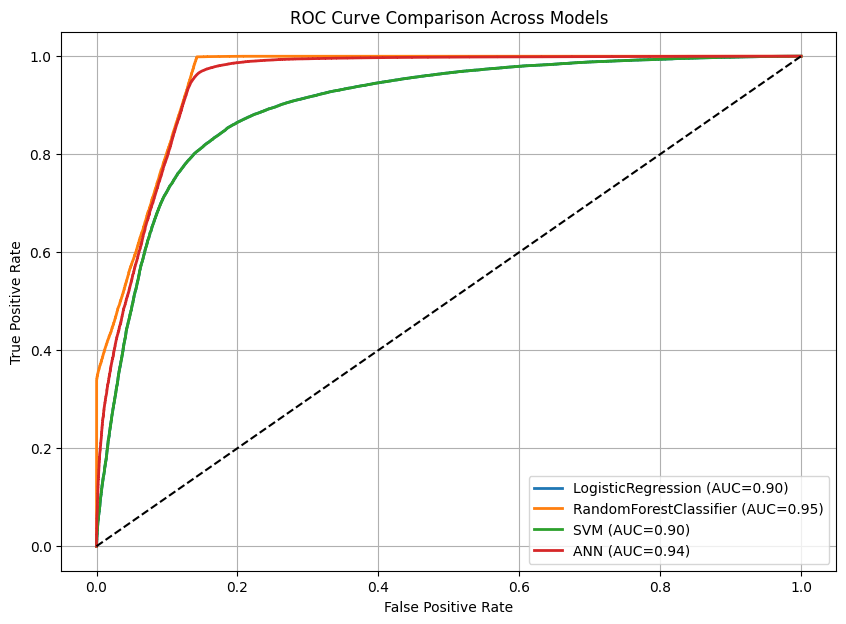

                    model  accuracy  precision  recall  f1  \
1  RandomForestClassifier        94         90     100  94   
3           MLPClassifier        91         90      94  92   
0      LogisticRegression        83         86      84  85   
2               LinearSVC        83         86      83  85   

                                         best_params  
1             {'n_estimators': 100, 'max_depth': 15}  
3  {'solver': 'adam', 'learning_rate_init': 0.001...  
0                        {'max_iter': 500, 'C': 0.1}  
2                                         {'C': 0.1}  


In [5]:
metrics_none = final_model(method=None)
print(metrics_none)

In [6]:
metrics_under = final_model(method="RandomUnderSampler")
print(metrics_under)

RandomUnderSampler Done!!!


C:\Users\JANANI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\JANANI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


                    model  accuracy  precision  recall  f1  \
1  RandomForestClassifier        94         90     100  94   
3           MLPClassifier        90         90      93  91   
0      LogisticRegression        83         87      81  84   
2               LinearSVC        83         88      80  84   

                                         best_params  
1             {'n_estimators': 100, 'max_depth': 15}  
3  {'solver': 'adam', 'learning_rate_init': 0.001...  
0                         {'max_iter': 500, 'C': 10}  
2                                         {'C': 0.1}  


In [7]:
metrics_smoteenn = final_model(method="SMOTEENN")
print(metrics_smoteenn)

Smote Done!!!


C:\Users\JANANI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\JANANI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


                    model  accuracy  precision  recall  f1  \
1  RandomForestClassifier        92         90      96  93   
3           MLPClassifier        91         90      94  92   
0      LogisticRegression        83         87      82  85   
2               LinearSVC        83         87      82  84   

                                         best_params  
1             {'n_estimators': 100, 'max_depth': 15}  
3  {'solver': 'adam', 'learning_rate_init': 0.01,...  
0                          {'max_iter': 500, 'C': 1}  
2                                        {'C': 0.01}  


In [8]:
# Add a column for method before concatenation
metrics_smoteenn["method"] = "SMOTEENN"
metrics_under["method"] = "RandomUnderSampler"
metrics_none["method"] = "Original"

# Concatenate all results
all_metrics = pd.concat([metrics_smoteenn, metrics_under, metrics_none],
                        ignore_index=True)

all_metrics_sorted = all_metrics.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

cols = list(all_metrics_sorted.columns)
new_order = ["model", "method"] + [c for c in cols if c not in ["model", "method"]]
all_metrics_sorted = all_metrics_sorted[new_order]

print(all_metrics_sorted.to_string(index=False))


                 model             method  accuracy  precision  recall  f1                                                                                        best_params
RandomForestClassifier           Original        94         90     100  94                                                             {'n_estimators': 100, 'max_depth': 15}
RandomForestClassifier RandomUnderSampler        94         90     100  94                                                             {'n_estimators': 100, 'max_depth': 15}
RandomForestClassifier           SMOTEENN        92         90      96  93                                                             {'n_estimators': 100, 'max_depth': 15}
         MLPClassifier           SMOTEENN        91         90      94  92  {'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (20,), 'activation': 'relu'}
         MLPClassifier           Original        91         90      94  92 {'solver': 'adam', 'learning_rate_init': 0.001, 'hidden

In [9]:
def evaluate_best_model(model_metrics, X_train, y_train, X_test, y_test):
    
    best_model_name = model_metrics.iloc[0]['model']
    print("Best model from DataFrame:", best_model_name)

    best_params = model_metrics.iloc[0]['best_params']

    best_model = RandomForestClassifier(n_jobs=-1, random_state=42, **best_params).fit(X_train, y_train)

    # SHAP
    print("SHAP")
    explainer = shap.TreeExplainer(best_model)
    X_test_subset = X_test.iloc[:200]

    shap_values = explainer.shap_values(X_test_subset)
    print("SHAP shape:", shap_values.shape)

    print("X_test_subset shape:", X_test_subset.shape)

    shap_values_class1 = shap_values[:, :, 1]    #(n_samples, n_features, n_classes)  choose class 1 for Churn

    print("Fixed SHAP shape:", shap_values_class1.shape)  # (500, 9)

    shap.summary_plot(shap_values_class1, X_test_subset)
    shap.summary_plot(shap_values_class1, X_test_subset, plot_type="bar")
    shap.summary_plot(shap_values_class1, X_test_subset, plot_type="violin")

Best model from DataFrame: RandomForestClassifier
SHAP
SHAP shape: (200, 9, 2)
X_test_subset shape: (200, 9)
Fixed SHAP shape: (200, 9)


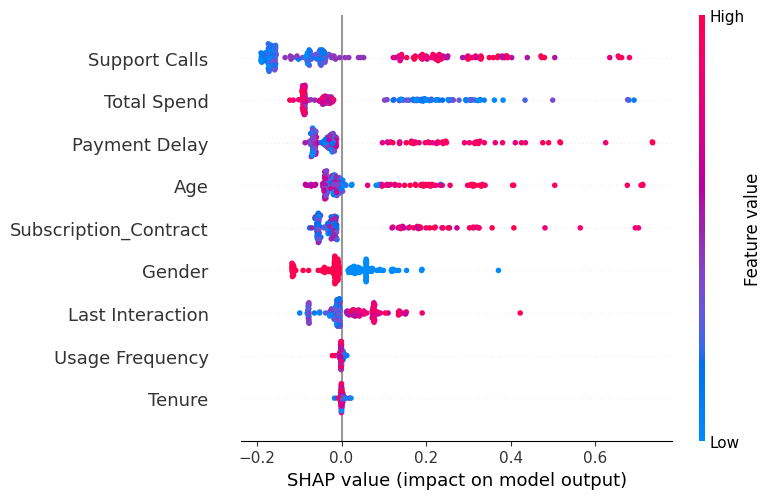

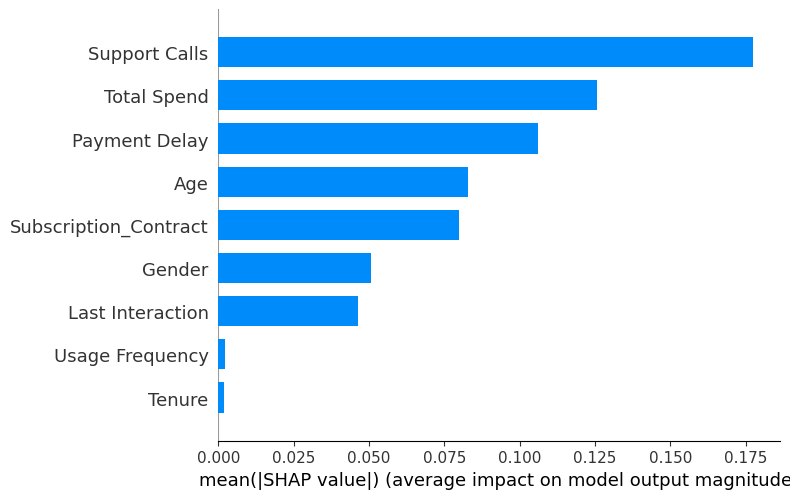

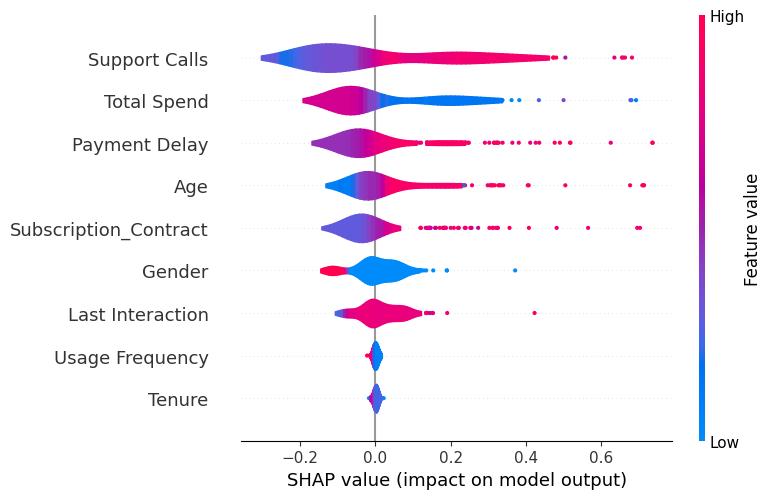

In [10]:
evaluate_best_model(all_metrics_sorted, X_train, y_train, X_test, y_test)